# 4.2.3. BÀI TẬP TRÊN LỚP: HỆ THỐNG GỢI Ý PHIM (MOVIELENS)

**Mục tiêu:**
Sử dụng dữ liệu đánh giá phim **MovieLens 100K** để tìm ra các luật kết hợp.
* **Input:** Lịch sử đánh giá phim của người dùng.
* **Output:** Các luật dạng *"Nếu người dùng thích phim A, họ cũng sẽ thích phim B"*.

**Nguồn dữ liệu:** [GroupLens - MovieLens 100K Dataset](https://grouplens.org/datasets/movielens/100k/)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import warnings

# Cấu hình hiển thị
warnings.filterwarnings('ignore')

# --- ĐỊNH NGHĨA ĐƯỜNG DẪN DỮ LIỆU ---
# Sửa lại theo yêu cầu của bạn
# Lưu ý: Đảm bảo bạn đã tạo thư mục 'data' và 'ml-100k' và bỏ file u.data, u.item vào đó
folder_path = "data/ml-100k" # Mình đổi thành "/" để tránh lỗi cú pháp Python

data_filename = folder_path + "/u.data"
movie_name_filename = folder_path + "/u.item"

print(f"Đang đọc dữ liệu từ: {data_filename}")

# --- ĐỌC DỮ LIỆU ---
try:
    # 1. Đọc file u.data (User ratings)
    # File này phân cách bằng tab (\t)
    data_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
    ratings = pd.read_csv(data_filename, sep='\t', names=data_cols, encoding='latin-1')

    # 2. Đọc file u.item (Movie titles)
    # File này phân cách bằng dấu gạch đứng (|)
    item_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url']
    movies = pd.read_csv(movie_name_filename, sep='|', names=item_cols, usecols=range(5), encoding='latin-1')

    print(" Đọc dữ liệu thành công!")
    print(f"Số lượng đánh giá: {ratings.shape[0]}")
    print(f"Số lượng bộ phim: {movies.shape[0]}")
    
    # Hiển thị thử dữ liệu
    display(ratings.head(3))
    display(movies.head(3))

except FileNotFoundError:
    print(" LỖI: Không tìm thấy file!")
    print(f"Bạn vui lòng kiểm tra xem file 'u.data' đã nằm đúng trong thư mục '{folder_path}' chưa nhé.")

Đang đọc dữ liệu từ: data/ml-100k/u.data
 Đọc dữ liệu thành công!
Số lượng đánh giá: 100000
Số lượng bộ phim: 1682


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116


,movie_id,title,release_date,video_release_date,imdb_url
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...


## Bước 2: Xử lý và Chuyển đổi dữ liệu

Khác với dữ liệu siêu thị (chỉ có mua/không mua), dữ liệu phim có số điểm đánh giá (1-5 sao).
Để áp dụng Apriori, chúng ta cần định nghĩa thế nào là **"Thích"**:
* **Giả định:** Người dùng chỉ thực sự thích phim nếu họ chấm điểm **>= 4 sao**.
* **Chuyển đổi:** Tạo ma trận User-Movie, trong đó:
    * 1: Người dùng đã xem và chấm >= 4 sao.
    * 0: Người dùng chưa xem hoặc chấm thấp.

In [15]:
# 1. Kết hợp bảng Rating và bảng Movie Name
df = pd.merge(ratings, movies, on='movie_id')

# 2. Lọc ra các đánh giá "Tích cực" (Favorable > 3 sao)
# Vì chúng ta muốn tìm luật: Thích A -> Thích B (chứ không phải Ghét A -> Ghét B)
favorable_ratings = df[df['rating'] > 3]

# 3. Tạo Giỏ hàng (User-Movie Matrix)
# Dòng là User, Cột là Tên phim
print("⏳ Đang tạo ma trận User-Movie (Bước này có thể mất vài giây)...")
basket = (favorable_ratings
          .groupby(['user_id', 'title'])['rating']
          .count().unstack().reset_index().fillna(0)
          .set_index('user_id'))

# 4. Mã hóa nhị phân (One-hot Encoding)
def encode_hot(x):
    return 1 if x >= 1 else 0

basket_sets = basket.applymap(encode_hot)

print(" Đã xử lý xong!")
print(f"Kích thước ma trận: {basket_sets.shape} (Users x Movies)")
# Xem thử 1 user đã thích những phim nào
print("\nVí dụ User ID 1 thích các phim:")
print(basket_sets.loc[1][basket_sets.loc[1] == 1].index.tolist()[:5]) # In 5 phim đầu

⏳ Đang tạo ma trận User-Movie (Bước này có thể mất vài giây)...
 Đã xử lý xong!
Kích thước ma trận: (942, 1434) (Users x Movies)

Ví dụ User ID 1 thích các phim:
['12 Angry Men (1957)', '2001: A Space Odyssey (1968)', 'Akira (1988)', 'Aladdin (1992)', 'Alien (1979)']


## Bước 3: Khai phá Luật kết hợp

Do dữ liệu phim rất thưa (Sparse) - một người chỉ xem một phần rất nhỏ trong hàng nghìn bộ phim, nên chúng ta cần điều chỉnh tham số:
* `min_support`: Đặt thấp (ví dụ 0.1) vì hiếm có bộ phim nào được >50% người cùng thích.
* `min_confidence`: Đặt cao (ví dụ 0.8) để tìm các luật thật sự chắc chắn.

In [6]:
# 1. Tìm tập phổ biến (Frequent Itemsets)
# min_support = 0.07 (Phim phải được ít nhất 7% người dùng thích)
print("⏳ Đang chạy Apriori...")
frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

print(f"-> Tìm thấy {len(frequent_itemsets)} tập phổ biến.")

# 2. Sinh luật kết hợp
# Lấy các luật có độ tin cậy > 80% (Rất cao)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

print(f"-> Tìm thấy {len(rules)} luật kết hợp mạnh.")

# Sắp xếp theo Confidence giảm dần
top_rules = rules.sort_values(by='confidence', ascending=False)
display(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

⏳ Đang chạy Apriori...
-> Tìm thấy 34536 tập phổ biến.
-> Tìm thấy 64799 luật kết hợp mạnh.


,antecedents,consequents,support,confidence,lift
64785,"(Terminator, The (1984), Fugitive, The (1993),...",(Raiders of the Lost Ark (1981)),0.070064,1.0,2.706897
55048,"(Terminator, The (1984), Princess Bride, The (...",(Raiders of the Lost Ark (1981)),0.077495,1.0,2.706897
43233,"(Return of the Jedi (1983), Empire Strikes Bac...",(Star Wars (1977)),0.073248,1.0,1.880240
60974,"(Princess Bride, The (1987), Raiders of the Lo...",(Star Wars (1977)),0.070064,1.0,1.880240
46631,"(Indiana Jones and the Last Crusade (1989), Ra...",(Star Wars (1977)),0.073248,1.0,1.880240
60997,"(Princess Bride, The (1987), Silence of the La...",(Star Wars (1977)),0.077495,1.0,1.880240
61005,"(Princess Bride, The (1987), Terminator 2: Jud...",(Star Wars (1977)),0.071125,1.0,1.880240
64691,"(Terminator, The (1984), Princess Bride, The (...",(Star Wars (1977)),0.075372,1.0,1.880240
64693,"(Terminator, The (1984), Princess Bride, The (...",(Raiders of the Lost Ark (1981)),0.075372,1.0,2.706897
54997,"(Princess Bride, The (1987), Pulp Fiction (199...",(Star Wars (1977)),0.070064,1.0,1.880240


### 🔎 Nhận xét kết quả:
* **Antecedents:** Phim điều kiện (Nếu xem phim này...)
* **Consequents:** Phim hệ quả (...thì sẽ thích phim kia).
* **Insight:** Các bộ phim trong cùng một series (như Star Wars) hoặc cùng thể loại (Hành động, Viễn tưởng) thường có sự kết hợp rất mạnh.

## Bước 4: Trực quan hóa Mạng lưới phim (Network Graph)

Để bài làm thêm phần ấn tượng và "xịn xò", chúng ta sẽ vẽ biểu đồ mạng lưới thể hiện sự kết nối giữa các bộ phim.
*(Lưu ý: Chỉ vẽ 50 luật mạnh nhất để biểu đồ không bị rối)*.

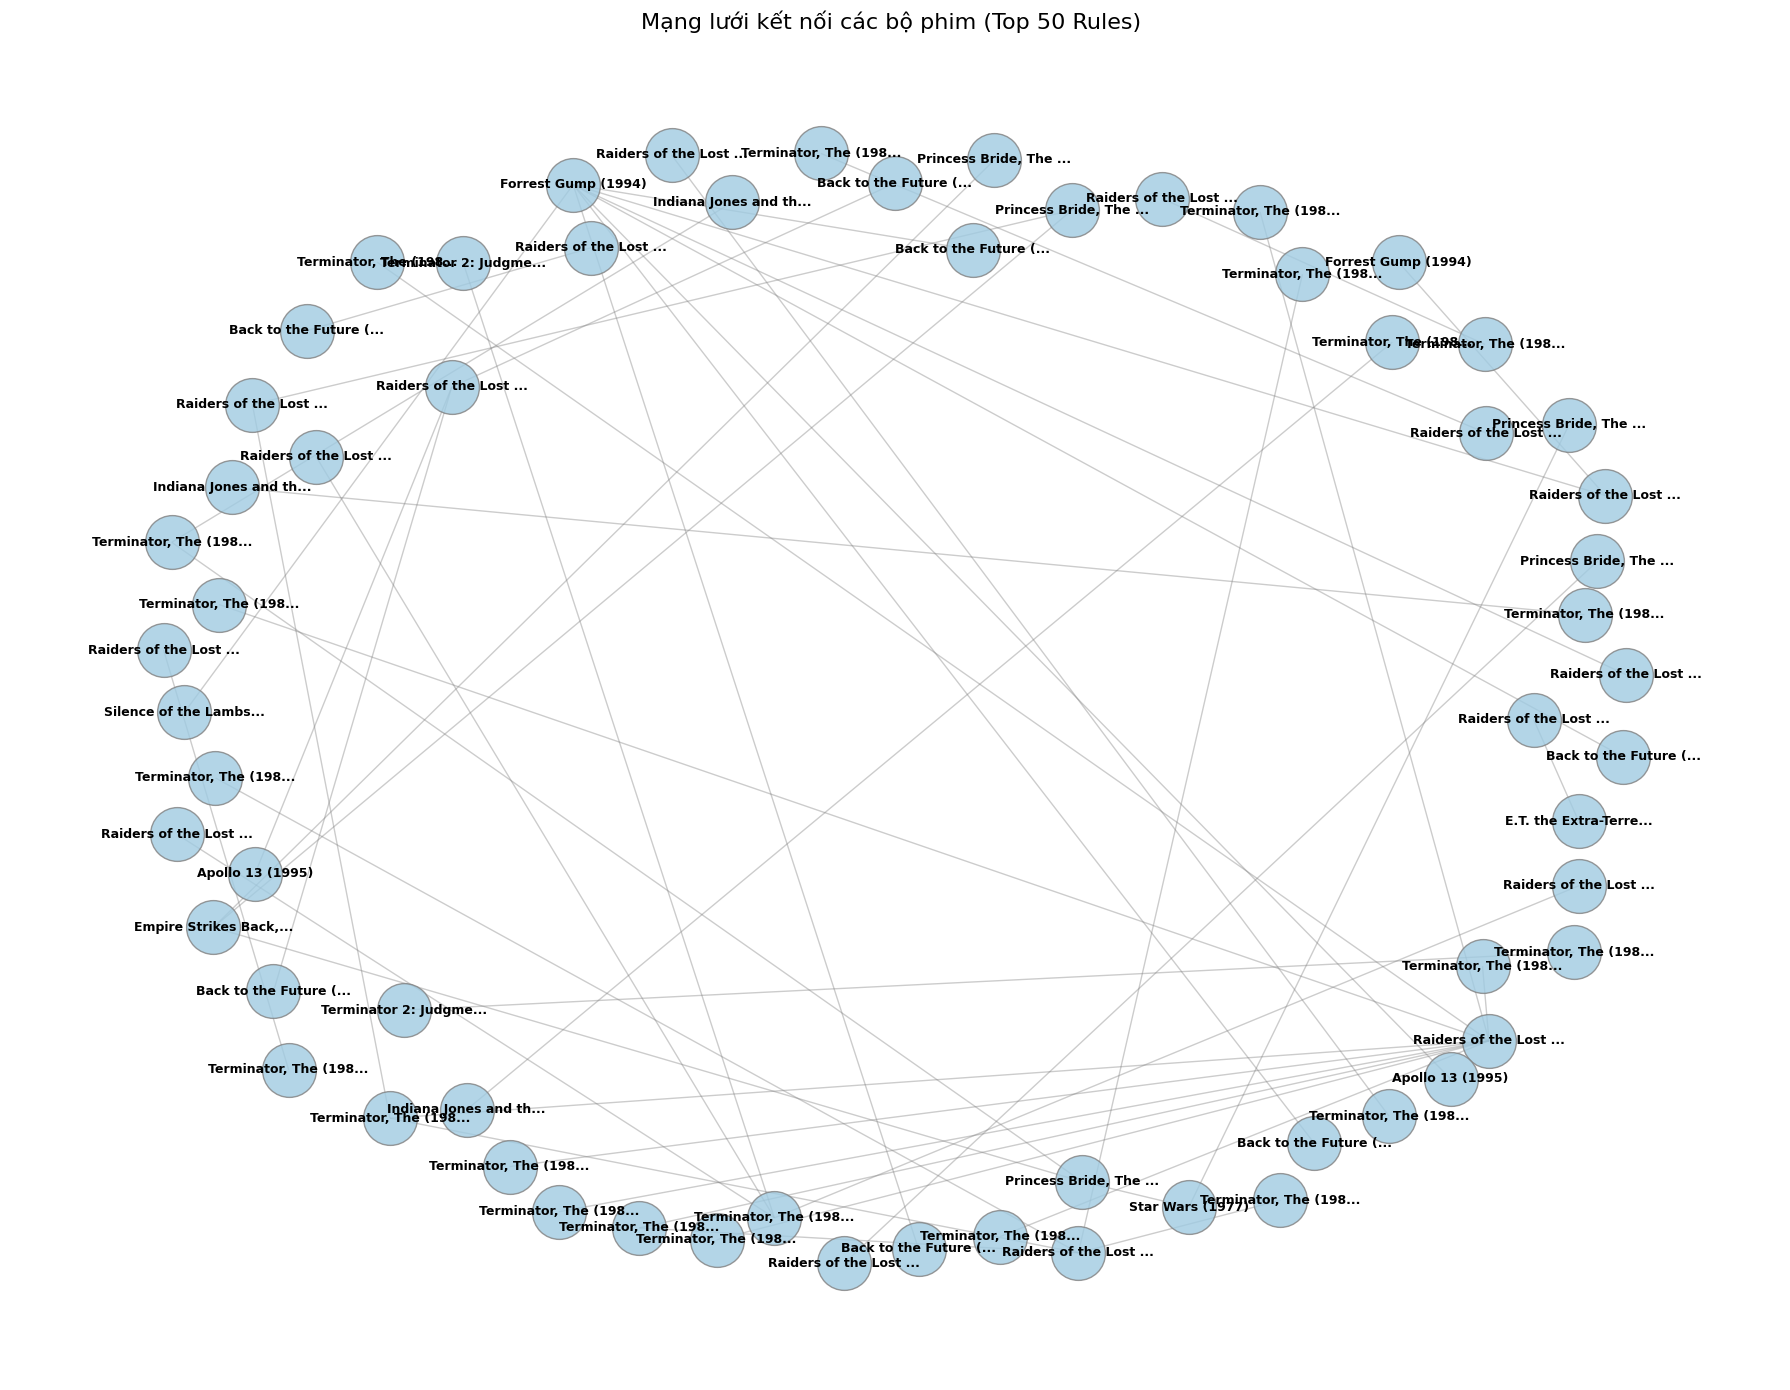

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Lấy dữ liệu (như cũ)
top_rules_plot = rules.sort_values(by='lift', ascending=False).head(50)

# 2. Tạo đồ thị
G = nx.from_pandas_edgelist(top_rules_plot,
                            source='antecedents',
                            target='consequents',
                            edge_attr='lift')

# --- CÁC CẢI TIẾN HIỂN THỊ ---

# A. Tăng kích thước khung hình lên (Rộng x Cao)
plt.figure(figsize=(18, 14)) 

# B. Tinh chỉnh bố cục (Layout)
# k=2.0 (Tăng lực đẩy giữa các nút, mặc định là rất nhỏ ~0.1-0.3)
# iterations=50 (Cho thuật toán chạy lâu hơn để tìm vị trí tối ưu)
# seed=42 (Giữ cố định vị trí, không bị nhảy lung tung mỗi lần chạy lại)
pos = nx.spring_layout(G, k=2.5, iterations=50, seed=42)

# C. Xử lý nhãn (Rút gọn tên phim dài)
def shorten_label(node_value):
    # Lấy tên phim từ frozenset
    text = list(node_value)[0]
    # Nếu dài hơn 20 ký tự thì cắt bớt
    if len(text) > 20:
        return text[:20] + "..."
    return text

labels = {node: shorten_label(node) for node in G.nodes()}

# D. Vẽ Đồ thị
# Vẽ nút nhỏ hơn chút (node_size=1500) và màu nhạt hơn để làm nền cho chữ
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='#A0CBE2', edgecolors='grey', alpha=0.8)

# Vẽ cạnh (mỏng lại và cong nhẹ để đỡ rối mắt)
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.4, edge_color='gray', 
                       connectionstyle="arc3,rad=0.1") # Làm cong đường nối

# Vẽ nhãn (Font nhỏ vừa phải, in đậm để dễ đọc)
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_family='sans-serif', font_weight='bold')

plt.title('Mạng lưới kết nối các bộ phim (Top 50 Rules) ', fontsize=16)
plt.axis('off')
plt.tight_layout() # Tự động căn lề
plt.show()

# KẾT LUẬN BÀI TẬP TRÊN LỚP

Từ phân tích trên, chúng ta rút ra được các kết luận quan trọng cho hệ thống gợi ý:
1.  **Hiệu ứng Series:** Các luật mạnh nhất thường rơi vào các bộ ba kinh điển như *Star Wars (IV, V, VI)*. Nếu người dùng thích một phần, xác suất gần 100% họ sẽ thích các phần còn lại.
2.  **Cụm thể loại:** Biểu đồ mạng lưới cho thấy các cụm phim (Cluster) rõ rệt. Ví dụ: Cụm phim hành động/viễn tưởng (Terminator, Aliens) thường đi cùng nhau.
3.  **Ứng dụng:** Có thể sử dụng các luật này để gợi ý phim ngay lập tức cho người dùng mới khi họ vừa đánh giá tốt một bộ phim bất kỳ.